<a href="https://colab.research.google.com/github/crahulnaidu/quantum_computing/blob/main/month_1/month_1_day_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install qiskit
!pip install qiskit-aer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 42.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 35.2 MB/s eta 0:00:00


In [24]:
from qiskit import QuantumCircuit,transpile
from qiskit_aer import AerSimulator,Aer
from qiskit.visualization import plot_histogram

In [3]:
n=2
grover_circuit=QuantumCircuit(2)


In [4]:
def grover_initialize(qc,qubits):
  for q in qubits:
    qc.h(q)
  return qc

In [5]:
grover_circuit=grover_initialize(grover_circuit,[0,1])
grover_circuit.draw()

┌───┐
q_0: ┤ H ├
     ├───┤
q_1: ┤ H ├
     └───┘

In [27]:
def grover_oracle(nqubits,target_state='111'):
  qc=QuantumCircuit(nqubits)

  if target_state=="111":
    qc.mcx(list(range(nqubits-1)),nqubits-1)

  oracle_gate=qc.to_gate()
  oracle_gate.name="Oracle"
  return oracle_gate


In [28]:
def diffuser(nqubits):
  qc=QuantumCircuit(nqubits)

  for q in range(nqubits):
    qc.h(q)

  for q in range(nqubits):
    qc.x(q)

  qc.h(nqubits-1)
  qc.mcx(list(range(nqubits-1)),nqubits-1)
  qc.h(nqubits-1)

  for q in range(nqubits):
    qc.x(q)

  for q in range(nqubits):
    qc.h(q)

  U_s=qc.to_gate()
  U_s.name="U$_$"
  return U_s

In [29]:
n=3
grover_circuit=QuantumCircuit(n)
grover_circuit=grover_initialize(grover_circuit,[0,1,2])
grover_circuit.append(grover_oracle(n),range(n))
grover_circuit.append(diffuser(n),range(n))
grover_circuit.measure_all()
grover_circuit.draw()

┌───┐┌─────────┐┌───────┐ ░ ┌─┐      
   q_0: ┤ H ├┤0        ├┤0      ├─░─┤M├──────
        ├───┤│         ││       │ ░ └╥┘┌─┐   
   q_1: ┤ H ├┤1 Oracle ├┤1 U$_$ ├─░──╫─┤M├───
        ├───┤│         ││       │ ░  ║ └╥┘┌─┐
   q_2: ┤ H ├┤2        ├┤2      ├─░──╫──╫─┤M├
        └───┘└─────────┘└───────┘ ░  ║  ║ └╥┘
meas: 3/═════════════════════════════╩══╩══╩═
                                     0  1  2

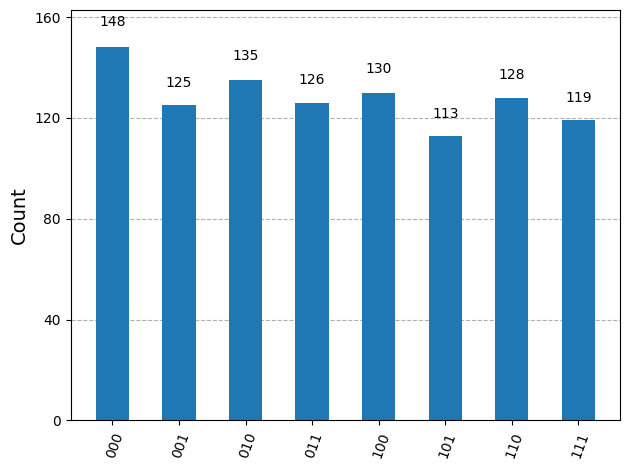

In [30]:
qasm_sim=Aer.get_backend('qasm_simulator')
transpiled_grover_circuit = transpile(grover_circuit, qasm_sim)
results = qasm_sim.run(transpiled_grover_circuit).result()
counts = results.get_counts()
plot_histogram(counts)